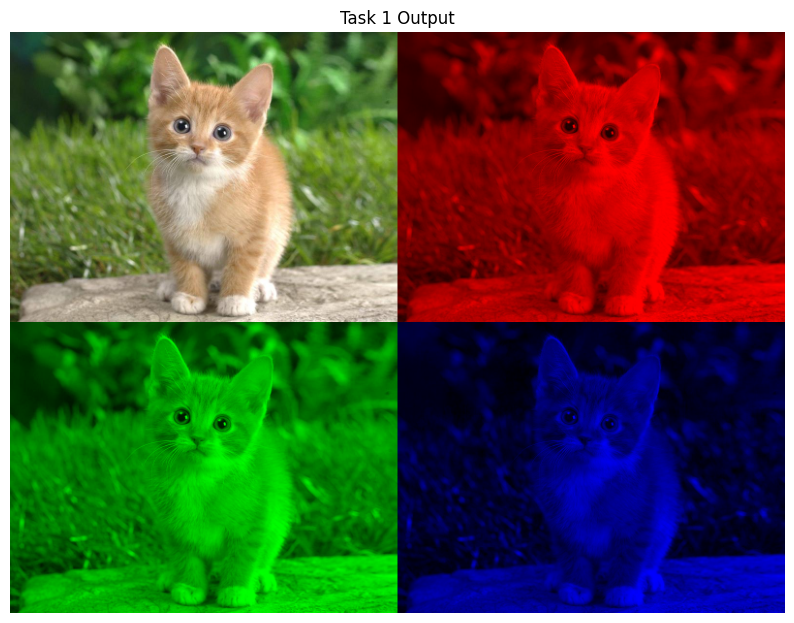

In [ ]:
# Task 1: The original image is in the form of 600x800x3 format. At the end, you have to generate an image that looks like to below output.
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the Image and Convert to RGB
try:
    original_image = cv2.imread('cat1.jpg')
    original_image_rgb = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
except Exception as e:
    print(f"Error: 'cat1.jpg' file not found. Please upload the picture. \n{e}")

# 2. We resize the Image by a factor of 0.5
resized_img = cv2.resize(original_image_rgb, (0, 0), fx=0.5, fy=0.5)
h, w, _ = resized_img.shape

#We create a layer of zeros for the empty channels
zeros = np.zeros((h, w), dtype="uint8")

#Top Left: Resized original image
top_left = resized_img

#Top Right: V channel of HSV, to be displayed in Red tones
hsv_img = cv2.cvtColor(resized_img, cv2.COLOR_RGB2HSV)
_, _, v_channel = cv2.split(hsv_img)
# We are placing the V channel into the Red channel
top_right = cv2.merge([v_channel, zeros, zeros])

# Bottom Left: L channel of Lab, to be displayed in Green tones
lab_img = cv2.cvtColor(resized_img, cv2.COLOR_RGB2Lab)
l_channel, _, _ = cv2.split(lab_img)
# We are placing the L channel into the Green channel
bottom_left = cv2.merge([zeros, l_channel, zeros])

# Bottom Right: B channel of RGB, to be displayed in Blue tones
_, _, b_channel = cv2.split(resized_img)
# We are placing the B channel into the Blue channel
bottom_right = cv2.merge([zeros, zeros, b_channel])


# 3. Combine All Parts
top_row = np.hstack((top_left, top_right))
bottom_row = np.hstack((bottom_left, bottom_right))
final_image = np.vstack((top_row, bottom_row))

# 4. Display the Result
plt.figure(figsize=(10, 8))
plt.imshow(final_image)
plt.title('Task 1 Output')
plt.axis('off')
plt.show()

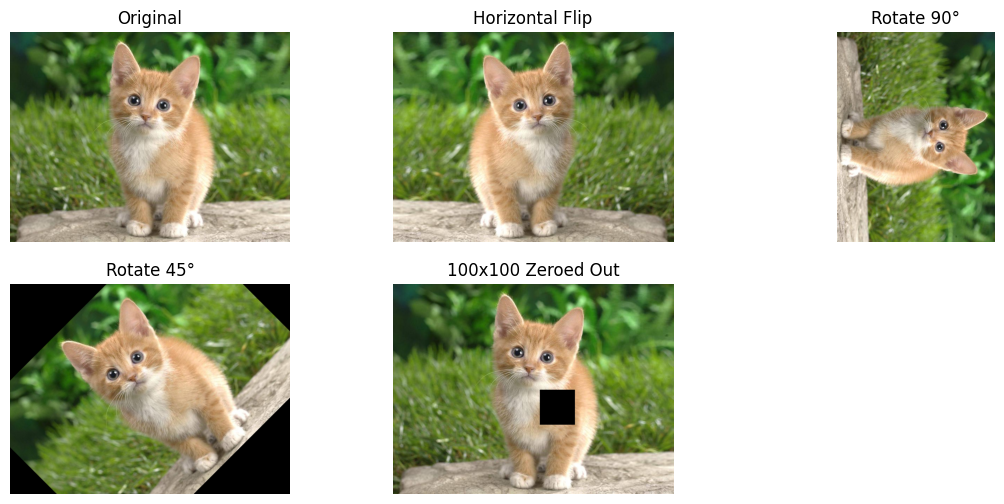

In [ ]:
# Task 2: flip, rotate 90, rotate 45, random 100x100 zero

flip_h = cv2.flip(original_image, 1)# in BGR format
rot90 = cv2.rotate(original_image, cv2.ROTATE_90_CLOCKWISE)

# 45 degrees
(h0, w0) = original_image.shape[:2]
center = (w0 // 2, h0 // 2)
M = cv2.getRotationMatrix2D(center, 45, 1.0)
rot45 = cv2.warpAffine(original_image, M, (w0, h0))

# random 100x100 zeroing
img_zero = original_image.copy()
x = np.random.randint(0, max(1, w0 - 100))
y = np.random.randint(0, max(1, h0 - 100))
img_zero[y:y+100, x:x+100] = 0

# Display (BGR->RGB for matplotlib)
plt.figure(figsize=(14, 6))
titles = ["Original", "Horizontal Flip", "Rotate 90°", "Rotate 45°", "100x100 Zeroed Out"]
imgs = [original_image, flip_h, rot90, rot45, img_zero]
for i, im in enumerate(imgs):
    plt.subplot(2, 3, i + 1)
    plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    plt.title(titles[i])
    plt.axis("off")
plt.show()

Blue X count (filtered): 26


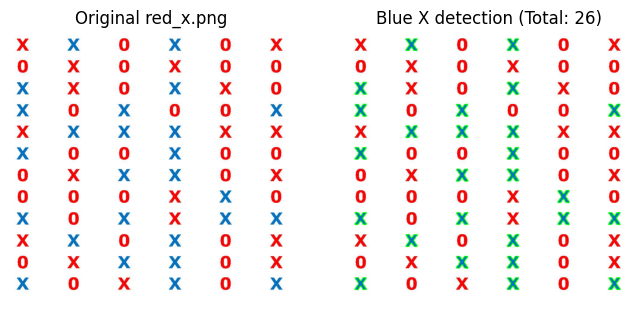

In [ ]:
# Task 3: blue X count
xo_bgr = cv2.imread("red_x.png")
if xo_bgr is None:
    raise FileNotFoundError("red_x.png not found. Check the file name and path.")

# 1) Convert to HSV
xo_hsv = cv2.cvtColor(xo_bgr, cv2.COLOR_BGR2HSV)

# 2) Use a more reliable blue range
lower_blue = np.array([90, 40, 40])
upper_blue = np.array([140, 255, 255])
mask = cv2.inRange(xo_hsv, lower_blue, upper_blue)

# 3) Morphological operations to reduce noise
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=1)

# 4) Find contours and apply an area filter
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
min_area = 300   # Increase/decrease according to the size of X. Eliminates small noise.

valid_cnts = []
for cnt in contours:
    area = cv2.contourArea(cnt)
    if area >= min_area:
        valid_cnts.append(cnt)

count_blue_X = len(valid_cnts)
print("Blue X count (filtered):", count_blue_X)

# 5) Display by drawing contours (in green)
xo_result = xo_bgr.copy()
cv2.drawContours(xo_result, valid_cnts, -1, (0,255,0), 2)

plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.title("Original red_x.png")
plt.imshow(cv2.cvtColor(xo_bgr, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1,2,2)
plt.title(f"Blue X detection (Total: {count_blue_X})")
plt.imshow(cv2.cvtColor(xo_result, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()